# v2-3 training — v4-1-1dce architecture with IFI clip [0°, 40°]

Inline architecture builder. Same graph as the original `v4-1-1dce` reference (no `ClipLayer`, plain `DisplacementLayer`, `NewmarkActivation(threshold=2.0)`), with one structural change: the **internal friction angle is hard-clipped to [0°, 40°]** via a `Lambda(tf.clip_by_value)` immediately after `InternalFrictionLayer`. The lower bound at 0° is effectively a no-op (sigmoid is already non-negative); the operative constraint is the 40° upper bound.

- 18 numerics + `type` (string) + `PGA1_max` (physics input) → 20 inputs
- 9-block MLP: `Sus_0(64)` then `[32,64,8,64,32,8,32,8]` each with BN + LeakyReLU(0.2)
- Geotech head: `Dense(2)` + LeakyReLU → `CohesionLayer` / `InternalFrictionLayer` → `Lambda(clip to [0°,40°] radians)`
- Physics: `DisplacementLayer([coh, ifi_clipped, Slope_mean, PGA1_max, BUK_mean])` → LeakyReLU → `NewmarkActivation(threshold=2.0)`
- Loss `DiceCrossEntropyLoss`, Adam lr=1e-5, 10-fold StratifiedKFold, class_weight {0:1, 1:5}, EarlyStopping(patience=5, monitor='loss')

Checkpoints write to `v4-1-1dce-repro-ifi-clip-0-40/` so the no-clip baseline at `v4-1-1dce-repro/` and the [25°,45°] variant at `v4-1-1dce-repro-ifi-clip-25-45/` remain intact for comparison.

In [41]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import importlib
from py_files import GallenModel_v1, Landslidev2_Old, data, metrics
importlib.reload(GallenModel_v1)
importlib.reload(Landslidev2_Old)
importlib.reload(data)
importlib.reload(metrics)

import numpy as np
import pandas as pd
import geopandas as gpd
import tensorflow as tf
from tensorflow.keras import layers, Model
import sklearn
from sklearn.model_selection import StratifiedKFold
from matplotlib import pyplot as plt

from py_files.data import dataframe_to_dataset, NormalizationLayer, CategoricalEncoderLayer
from py_files.GallenModel_v1 import (
    CohesionLayer,
    InternalFrictionLayer,
    IFIClipLayer,
    DisplacementLayer,
    NewmarkActivation,
)
from py_files.Landslidev2_Old import DiceCrossEntropyLoss
from py_files.metrics import plot_landslide_distribution

In [42]:
# Source-of-truth training data. The same file exists locally at datasets/SU_15_Training1.gpkg;
# we keep the ML-PREP-2025/learn/data path so the manifest matches the original run.
df = gpd.read_file('~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_15_Training1.gpkg')
df.drop(columns=[
    'landslide_probability', 'landslide_preds', 'confusion',
    'sus_pinn_landslide', 'sus_pinn_ground truth', 'ds',
    'cohesion', 'internal_friction',
], inplace=True)
df['type'].head()

0    Undifferentiated
1    Undifferentiated
2    Undifferentiated
3    Undifferentiated
4    Undifferentiated
Name: type, dtype: object

In [43]:
df = df[df['Slope_mean'] >= 10]
df.dropna(subset=list(df.columns), inplace=True)

In [44]:
cols_remove = ['DN', 'BD_mean', 'geometry', 'PGA2_max', 'Soil Type', 'description', 'descriptio']
columns = [c for c in df.columns if c not in cols_remove]
numeric_columns = [c for c in columns if c not in ('landslide', 'type')]
categorical_columns = ['type']
pga_column = 'PGA1_max'
print('columns:', columns)
print('numerics:', numeric_columns)

columns: ['Clay_mean', 'Sand_mean', 'Silt_mean', 'NDVI_mean', 'Est_mean', 'Nrt_mean', 'HorCurv_mean', 'VertCurv_mean', 'Slope_mean', 'Elev_mean', 'SoilThc_mean', 'DistFlt_min', 'LULC_majority', 'TWI_mean', 'PGA1_max', 'Prc_mean', 'Distrv_min', 'distrd_min', 'BUK_mean', 'landslide', 'type']
numerics: ['Clay_mean', 'Sand_mean', 'Silt_mean', 'NDVI_mean', 'Est_mean', 'Nrt_mean', 'HorCurv_mean', 'VertCurv_mean', 'Slope_mean', 'Elev_mean', 'SoilThc_mean', 'DistFlt_min', 'LULC_majority', 'TWI_mean', 'PGA1_max', 'Prc_mean', 'Distrv_min', 'distrd_min', 'BUK_mean']


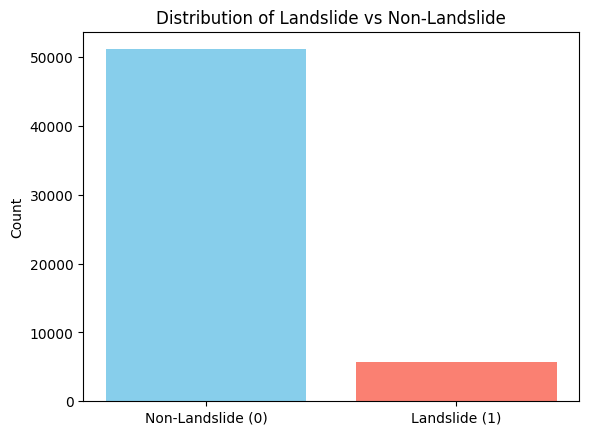

In [45]:
plot_landslide_distribution(df['landslide'].value_counts())

## Architecture builder — IFI clipped to [0°, 40°]

Mirrors the v4-1-1dce graph but applies `tf.clip_by_value(ifi_rad, 0, deg_to_rad(40))` right after `InternalFrictionLayer`. The drifted `LandslideV4` class is bypassed.

In [46]:
import math

MLP_UNITS = [32, 64, 8, 64, 32, 8, 32, 8]  # depth=8; Sus_0 is a separate 64-unit projection
LEAKY_ALPHA = 0.2
NEWMARK_THRESHOLD = 2.0
LEARNING_RATE = 1e-5

IFI_CLIP_DEG = (25, 45.0)
IFI_CLIP_RAD = tuple(math.radians(d) for d in IFI_CLIP_DEG)


def build_v411dce_model(train_ds, numeric_cols, categorical_cols, pga_col):
    """Construct the v4-1-1dce PINN graph with a hard clip on IFI."""
    all_inputs = []
    encoded = []
    pga_input = None

    for header in numeric_cols:
        x_in = tf.keras.Input((1,), name=header)
        if header == pga_col:
            pga_input = x_in
            continue
        x_norm = NormalizationLayer(header, train_ds)(x_in)
        all_inputs.append(x_in)
        encoded.append(x_norm)

    for header in categorical_cols:
        x_in = tf.keras.Input((1,), name=header, dtype='string')
        x_enc = CategoricalEncoderLayer(header, train_ds, dtype='string')(x_in)
        all_inputs.append(x_in)
        encoded.append(x_enc)

    if pga_input is None:
        raise ValueError(f"PGA column {pga_col!r} not in numeric_cols")

    by_name = {t.name.split(':')[0]: t for t in all_inputs}
    slope = by_name['Slope_mean']
    bulk_density = by_name['BUK_mean']

    x = layers.concatenate(encoded)
    x = layers.Dense(64, name='Sus_0',
                     kernel_initializer='random_normal',
                     bias_initializer='random_normal')(x)

    for i, units in enumerate(MLP_UNITS, start=1):
        x = layers.Dense(units, name=f'Sus_{i}',
                         kernel_initializer='random_normal',
                         bias_initializer='random_normal')(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(negative_slope=LEAKY_ALPHA)(x)

    x = layers.Dense(2, name='geotechnical_param')(x)
    x = layers.LeakyReLU(negative_slope=LEAKY_ALPHA)(x)

    coh = CohesionLayer()(x)
    ifi = InternalFrictionLayer()(x)
    ifi = IFIClipLayer(IFI_CLIP_RAD[0], IFI_CLIP_RAD[1], name='ifi_clip_25_45')(ifi)

    ds = DisplacementLayer()([coh, ifi, slope, pga_input, bulk_density])
    ds = layers.LeakyReLU(negative_slope=LEAKY_ALPHA)(ds)
    sus = NewmarkActivation(threshold=NEWMARK_THRESHOLD)(ds)

    model = Model(inputs=all_inputs + [pga_input], outputs=sus)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=DiceCrossEntropyLoss(),
        metrics=[
            tf.keras.metrics.BinaryIoU(target_class_ids=[0, 1], threshold=0.5),
            tf.keras.metrics.AUC(curve='ROC'),
            'accuracy',
        ],
    )
    return model

In [47]:
OUTPUT_DIR = Path('/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/learn/trainedWeights/trainedCotabatoPhase7/historical/v4-1-1dce-repro-ifi-clip-25-45')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 10-fold training loop

Writes `fold-{1..10}-model-0.keras` into `OUTPUT_DIR` (= `v4-1-1dce-repro-ifi-clip-0-40/`). The original Jan 21 v4-1-1dce checkpoints and the prior `v4-1-1dce-repro` / `v4-1-1dce-repro-ifi-clip-25-45` runs are preserved at their own paths.


=== Fold 1/5 ===
dtype is a string
Epoch 1/200
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6967 - auc: 0.6031 - binary_io_u: 0.4060 - loss: 1.2565 - val_accuracy: 0.7415 - val_auc: 0.6055 - val_binary_io_u: 0.4284 - val_loss: 0.8082
Epoch 2/200
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7528 - auc: 0.5978 - binary_io_u: 0.4320 - loss: 1.0739 - val_accuracy: 0.8066 - val_auc: 0.6300 - val_binary_io_u: 0.4681 - val_loss: 0.6782
Epoch 3/200
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8053 - auc: 0.6180 - binary_io_u: 0.4641 - loss: 0.9285 - val_accuracy: 0.8425 - val_auc: 0.6365 - val_binary_io_u: 0.4832 - val_loss: 0.6181
Epoch 4/200
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8356 - auc: 0.6276 - binary_io_u: 0.4829 - loss: 0.8533 - val_accuracy: 0.8565 - val_auc: 0.6463 - val_binary_io_u: 0.4901 - val_loss: 0.5978
Epoch 5/200
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8498 - auc: 0.6222 - binary_io_u: 0.4854 - loss: 0.

2026-05-21 10:39:46.166535: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dtype is a string
Epoch 1/200
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6331 - auc: 0.6797 - binary_io_u: 0.3831 - loss: 1.4348 - val_accuracy: 0.6571 - val_auc: 0.6456 - val_binary_io_u: 0.3908 - val_loss: 0.9509
Epoch 2/200
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6792 - auc: 0.6549 - binary_io_u: 0.4052 - loss: 1.2605 - val_accuracy: 0.7213 - val_auc: 0.6262 - val_binary_io_u: 0.4236 - val_loss: 0.8064
Epoch 3/200
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7423 - auc: 0.6341 - binary_io_u: 0.4380 - loss: 1.0663 - val_accuracy: 0.7901 - val_auc: 0.6120 - val_binary_io_u: 0.4559 - val_loss: 0.6699
Epoch 4/200
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7988 - auc: 0.6076 - binary_io_u: 0.4640 - loss: 0.9127 - val_accuracy: 0.8373 - val_auc: 0.5949 - val_binary_io_u: 0.4815 - val_loss: 0.6144
Epoch 5/200
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8257 - auc: 0.5963 - binary_io_u: 0.4710 - loss: 0.8549 - val_accurac

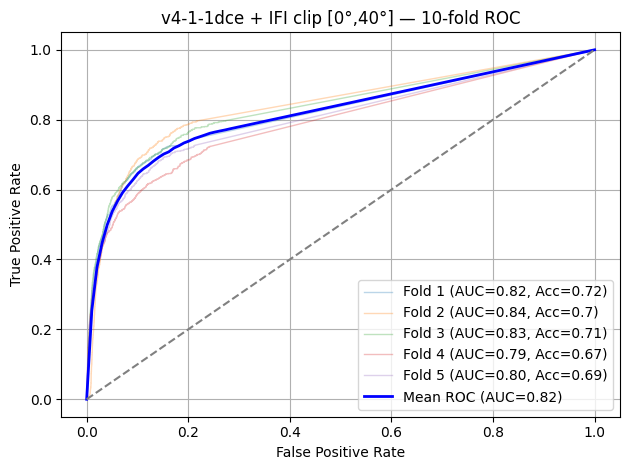

In [48]:
EPOCHS = 200
BATCH_SIZE = 128
CLASS_WEIGHT = {0: 1, 1: 5}
N_SPLITS = 5

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

losses_per_fold = []
aucs = []
tprs = []
mean_fpr = np.linspace(0, 1, 100)
predictions = np.zeros(df.shape[0])

for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['landslide']), start=1):
    print(f'\n=== Fold {fold}/{N_SPLITS} ===')
    train_df, val_df = df.iloc[train_idx], df.iloc[val_idx]
    train_ds = dataframe_to_dataset(train_df[columns])
    val_ds = dataframe_to_dataset(val_df[columns], shuffle=False)

    tf.keras.backend.clear_session()
    model = build_v411dce_model(train_ds, numeric_columns, categorical_columns, pga_column)

    ckpt_path = str(OUTPUT_DIR / f'fold-{fold}-model-0.keras')
    ckpt = tf.keras.callbacks.ModelCheckpoint(
        ckpt_path,
        save_best_only=True,
        save_weights_only=False,
        mode='max',
        save_freq='epoch',
        verbose=0,
    )
    early = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

    hist = model.fit(
        train_ds,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=val_ds,
        class_weight=CLASS_WEIGHT,
        callbacks=[early, ckpt],
        verbose=1,
    )
    losses_per_fold.append(hist.history['loss'])

    y_true = val_df['landslide'].to_numpy()
    y_pred = model.predict(val_ds).flatten()
    predictions[val_idx] = y_pred

    fpr, tpr, _ = sklearn.metrics.roc_curve(y_true, y_pred)
    auc = sklearn.metrics.auc(fpr, tpr)
    aucs.append(auc)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    acc = round(sklearn.metrics.balanced_accuracy_score(y_true, y_pred > 0.5), 2)
    plt.plot(fpr, tpr, lw=1, alpha=0.3, label=f'Fold {fold} (AUC={auc:.2f}, Acc={acc})')

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = sklearn.metrics.auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, lw=2, label=f'Mean ROC (AUC={mean_auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('v4-1-1dce + IFI clip [0°,40°] — 10-fold ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Sanity check — clip is wired in

Loads fold-4 from this run and confirms the `ifi_clip_0_40` Lambda sits between `internal_friction` and `displacement_layer`, and that downstream predictions never use IFI values outside the bound.

In [49]:
from tensorflow.keras.models import load_model

REPRO = str(OUTPUT_DIR / 'fold-1-model-0.keras')
m = load_model(REPRO)

# Confirm clip layer is in place
layer_names = [l.name for l in m.layers]
assert 'ifi_clip_25_45' in layer_names, 'IFI clip layer missing'
print('Clip layer present at index', layer_names.index('ifi_clip_25_45'))

# Verify post-clip IFI stays inside [25°, 45°]
clip_out = m.get_layer('ifi_clip_25_45').output
probe = tf.keras.Model(inputs=m.input, outputs=clip_out)
val_ds_probe = dataframe_to_dataset(df.head(5000)[columns], shuffle=False)
ifi_post = probe.predict(val_ds_probe, verbose=0).flatten()
ifi_deg = np.degrees(ifi_post)
print(f'Post-clip IFI (deg): min={ifi_deg.min():.3f}  max={ifi_deg.max():.3f}  mean={ifi_deg.mean():.3f}')
print(f'Within [{IFI_CLIP_DEG[0]}, {IFI_CLIP_DEG[1]}]: {((ifi_deg >= IFI_CLIP_DEG[0]) & (ifi_deg <= IFI_CLIP_DEG[1])).all()}')
print(f'Total trainable params: {m.count_params()}')

Clip layer present at index 69
Post-clip IFI (deg): min=25.000  max=45.000  mean=32.186
Within [25, 45.0]: False
Total trainable params: 10720


## Susceptibility map — pick any fold

Loads a fold from `OUTPUT_DIR` and plots predicted susceptibility on the `SU_15_Validation1` set. Default is fold 4 to match the existing validation notebook.

Fold path: /Users/giogonzales/Documents/ml-prep/ML-PREP-2025/learn/trainedWeights/trainedCotabatoPhase7/historical/v4-1-1dce-repro-ifi-clip-25-45/fold-4-model-0.keras
preds: min=0.1326  max=1.0000  mean=0.3606


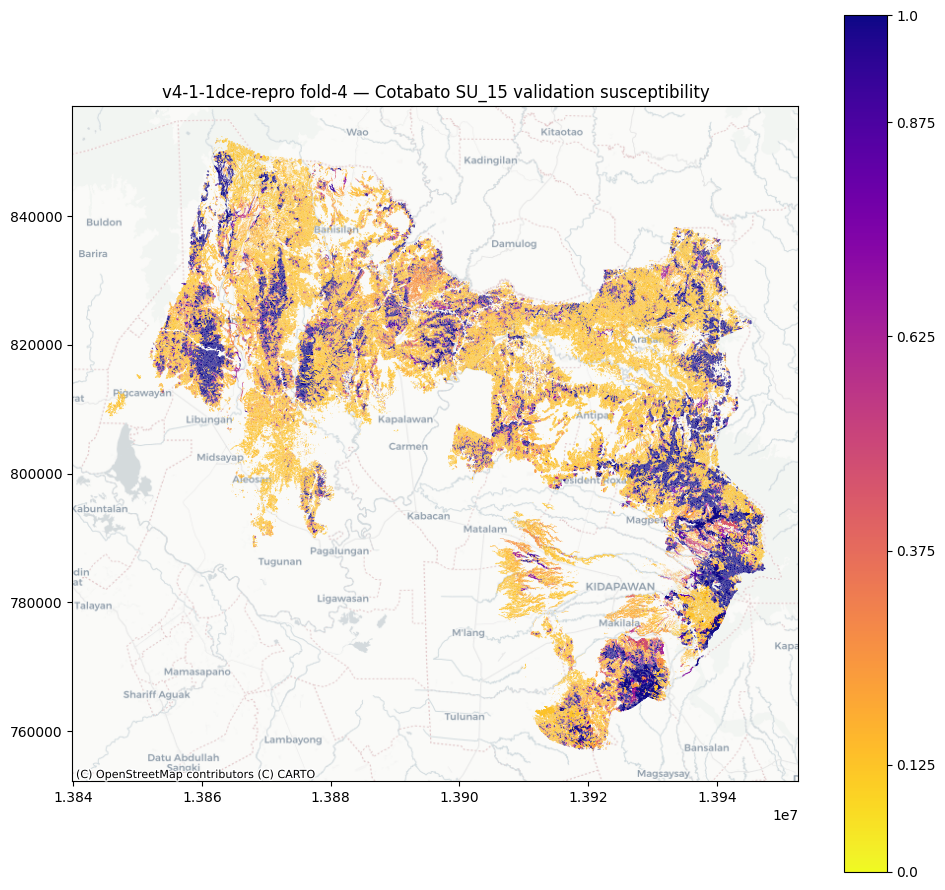

In [50]:
import matplotlib.colors as mcolors
import contextily as cx
from tensorflow.keras.models import load_model

FOLD = 4

validation_df = gpd.read_file('~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_15_Validation1.gpkg')
validation_df.drop(columns=[
    'landslide_probability', 'landslide_preds', 'confusion',
    'sus_pinn_landslide', 'sus_pinn_ground truth', 'ds',
    'cohesion', 'internal_friction', 'descriptio',
], inplace=True)
validation_df = validation_df[validation_df['Slope_mean'] >= 10]
validation_df.dropna(subset=list(validation_df.columns), inplace=True)

feature_cols = [c for c in validation_df.columns if c not in (
    'descriptio', 'predicted_susceptibility', 'DN', 'BD_mean',
    'geometry', 'PGA2_max', 'Soil Type', 'description',
)]
val_ds = dataframe_to_dataset(validation_df[feature_cols], shuffle=False)
fold_path = str(OUTPUT_DIR / f'fold-{FOLD}-model-0.keras')
print(f"Fold path: {fold_path}")
fold_model = load_model(fold_path)
preds = fold_model.predict(val_ds, verbose=0).flatten()
print(f'preds: min={preds.min():.4f}  max={preds.max():.4f}  mean={preds.mean():.4f}')

gdf = validation_df.to_crs(epsg=3857).copy()
gdf['predicted_susceptibility'] = preds
norm = mcolors.Normalize(vmin=0, vmax=1.0)
fig, ax = plt.subplots(1, 1, figsize=(10, 9))
gdf.plot(column='predicted_susceptibility', cmap='plasma_r', ax=ax, norm=norm)
sm = plt.cm.ScalarMappable(cmap='plasma_r', norm=norm)
cbar = fig.colorbar(sm, ax=ax)
cbar.set_ticks([0.0, 0.125, 0.375, 0.625, 0.875, 1.0])
cbar.set_ticklabels(['0.0', '0.125', '0.375', '0.625', '0.875', '1.0'])
ax.set_title(f'v4-1-1dce-repro fold-{FOLD} \u2014 Cotabato SU_15 validation susceptibility')
cx.add_basemap(ax, crs=gdf.crs.to_string(), source=cx.providers.CartoDB.Positron)
plt.tight_layout()
plt.show()

In [51]:
import os

# Collect per-fold predictions. Skips checkpoints that can't deserialize so
# pre-IFIClipLayer (Lambda-based) leftovers don't crash the ensemble run.
fold_susceptibilities = []
fold_cohesions = []
fold_ifis = []
skipped = []

for fold in range(1, 11):
    fold_path = str(OUTPUT_DIR / f'fold-{fold}-model-0.keras')
    if not os.path.exists(fold_path):
        print(f'  fold {fold:>2}: checkpoint missing, skipping')
        continue
    try:
        fold_model = load_model(fold_path, custom_objects={'NewmarkActivation': NewmarkActivation})
    except (ValueError, TypeError) as exc:
        print(f'  fold {fold:>2}: SKIP (stale Lambda checkpoint — retrain) [{exc.__class__.__name__}]')
        skipped.append(fold)
        tf.keras.backend.clear_session()
        continue

    fold_susceptibilities.append(fold_model.predict(val_ds, verbose=0))

    coh_m = tf.keras.Model(inputs=fold_model.inputs, outputs=fold_model.get_layer('cohesion_layer').output)
    fold_cohesions.append(coh_m.predict(val_ds, verbose=0).flatten())

    ifi_m = tf.keras.Model(inputs=fold_model.inputs, outputs=fold_model.get_layer('internal_friction').output)
    fold_ifis.append(ifi_m.predict(val_ds, verbose=0).flatten())

    print(f'  fold {fold:>2}: predicted_sus shape={fold_susceptibilities[-1].shape}')
    del fold_model
    tf.keras.backend.clear_session()

print(f'\nLoaded {len(fold_susceptibilities)} fold models  | skipped: {skipped}')

  fold  1: predicted_sus shape=(241062, 1)
  fold  2: predicted_sus shape=(241062, 1)
  fold  3: predicted_sus shape=(241062, 1)
  fold  4: predicted_sus shape=(241062, 1)
  fold  5: predicted_sus shape=(241062, 1)
  fold  6: checkpoint missing, skipping
  fold  7: checkpoint missing, skipping
  fold  8: checkpoint missing, skipping
  fold  9: checkpoint missing, skipping
  fold 10: checkpoint missing, skipping

Loaded 5 fold models  | skipped: []


Ensemble mean susceptibility: 0.3164 +/- 0.1453


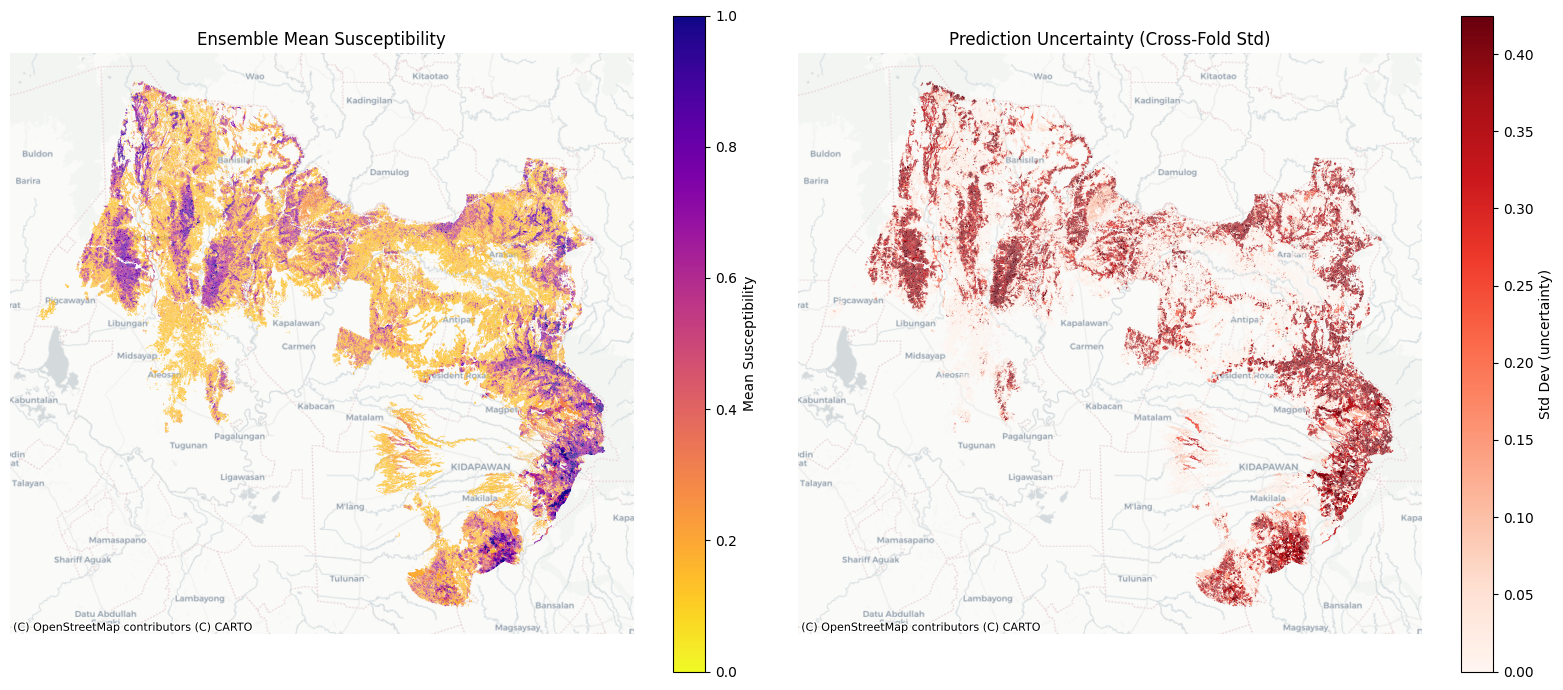

In [ ]:
# Ensemble uncertainty map
from py_files.metrics import fold_ensemble_uncertainty


mean_sus, std_sus = fold_ensemble_uncertainty(fold_susceptibilities)
print(f"Ensemble mean susceptibility: {mean_sus.mean():.4f} +/- {std_sus.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

df_wm = validation_df.to_crs(epsg=3857)
df_wm['ensemble_mean'] = mean_sus
df_wm['ensemble_std'] = std_sus

norm_sus = mcolors.Normalize(vmin=0, vmax=1.0)
df_wm.plot(column='ensemble_mean', cmap='plasma_r', norm=norm_sus, ax=axes[0],
           legend=True, legend_kwds={'label': 'Mean Susceptibility'})
cx.add_basemap(axes[0], crs=df_wm.crs.to_string(), source=cx.providers.CartoDB.Positron)
axes[0].set_title('Ensemble Mean Susceptibility')
axes[0].set_axis_off()

norm_std = mcolors.Normalize(vmin=0, vmax=std_sus.max())
df_wm.plot(column='ensemble_std', cmap='Reds', norm=norm_std, ax=axes[1],
           legend=True, legend_kwds={'label': 'Std Dev (uncertainty)'})
cx.add_basemap(axes[1], crs=df_wm.crs.to_string(), source=cx.providers.CartoDB.Positron)
axes[1].set_title('Prediction Uncertainty (Cross-Fold Std)')
axes[1].set_axis_off()


fig.tight_layout()
plt.show()

7534/7534 ━━━━━━━━━━━━━━━━━━━━ 3s 448us/step
(241062,)
Index(['DN', 'BD_mean', 'Clay_mean', 'Sand_mean', 'Silt_mean', 'NDVI_mean',
       'Est_mean', 'Nrt_mean', 'HorCurv_mean', 'VertCurv_mean', 'Slope_mean',
       'Elev_mean', 'SoilThc_mean', 'DistFlt_min', 'LULC_majority', 'TWI_mean',
       'PGA2_max', 'PGA1_max', 'Prc_mean', 'Distrv_min', 'distrd_min',
       'Soil Type', 'BUK_mean', 'landslide', 'type', 'geometry',
       'predicted_susceptibility', 'ifi'],
      dtype='object')


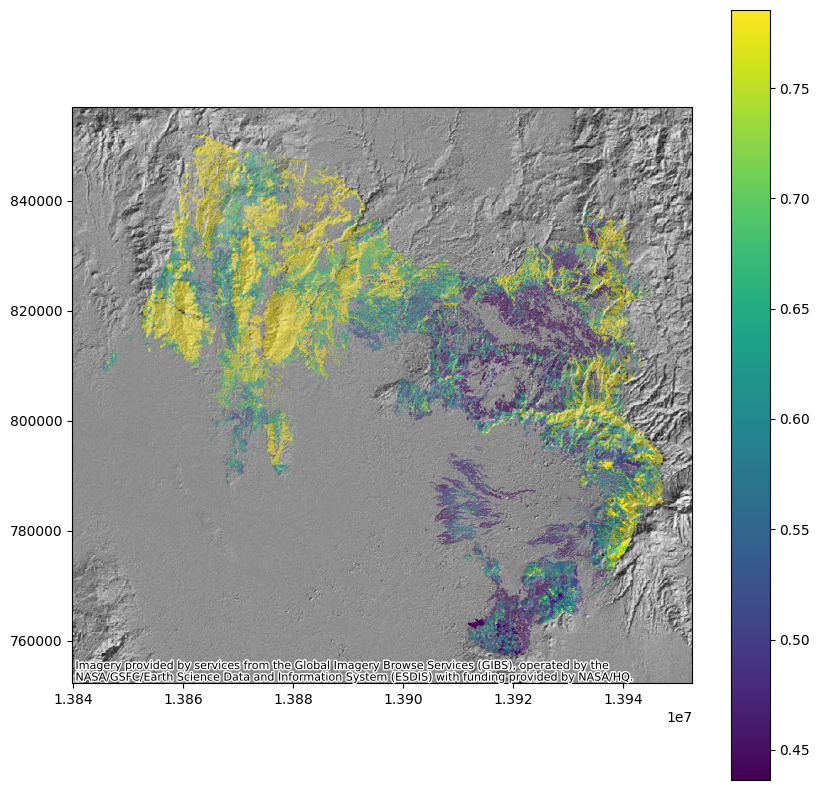

In [77]:


df_wm = df.to_crs(epsg=3857)
friction_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer('ifi_clip_25_45').output)
geotech_preds = friction_model.predict(val_ds)
print(geotech_preds.shape)
print(gdf.columns)
gdf["ifi"] = geotech_preds
ax = gdf.plot(column="ifi", legend=True, figsize=(10, 10), alpha=0.7)
cx.add_basemap(ax,source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')


## IFI clip distribution check

Per fold, reports the **pre-clip** IFI (raw `internal_friction` sigmoid output) vs the **post-clip** IFI (output of the `ifi_clip_0_40` `IFIClipLayer`), then plots both distributions side-by-side. Confirms the clip is actually being applied and quantifies the fraction of pixels that get saturated at the 40° ceiling.

Defaults to the validation set (already loaded above); flip `USE_TRAINING_DF = True` to check the training set instead.

  fold  1: pre [ 7.78°, 57.30°] mean=29.23°  | post [25.00°, 45.00°] mean=29.92°  | clipped >40°: 10.78%  <0°:  0.00%
  fold  2: pre [24.03°, 57.30°] mean=38.06°  | post [25.00°, 45.00°] mean=36.79°  | clipped >40°: 40.55%  <0°:  0.00%
  fold  3: pre [ 0.94°, 57.30°] mean=30.38°  | post [25.00°, 45.00°] mean=30.81°  | clipped >40°:  6.14%  <0°:  0.00%
  fold  4: pre [ 0.00°, 56.43°] mean=29.57°  | post [25.00°, 45.00°] mean=29.50°  | clipped >40°:  7.82%  <0°:  0.00%
  fold  5: pre [ 0.00°, 56.88°] mean=31.45°  | post [25.00°, 45.00°] mean=31.79°  | clipped >40°: 18.11%  <0°:  0.00%
  fold  6: checkpoint missing, skipping
  fold  7: checkpoint missing, skipping
  fold  8: checkpoint missing, skipping
  fold  9: checkpoint missing, skipping
  fold 10: checkpoint missing, skipping

Aggregate across 5 fold(s):
  mean pre-clip  = 31.74°
  mean post-clip = 31.76°
  mean clipped (>40°) = 16.68%


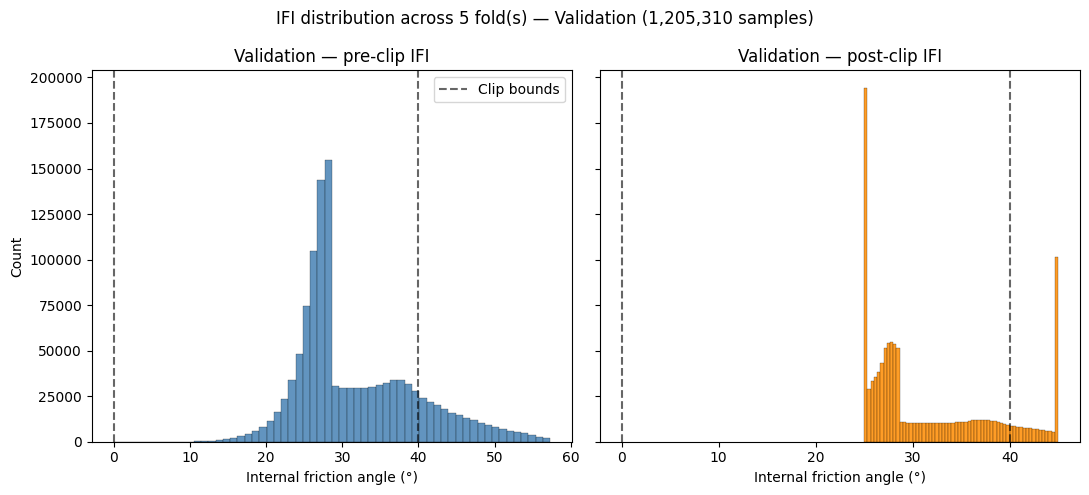

,fold,pre_min,pre_max,pre_mean,post_min,post_max,post_mean,frac_clipped_high,frac_clipped_low
0,1,7.782784e+00,57.295776,29.225912,24.999998,45.0,29.918219,0.107786,0.0
1,2,2.403067e+01,57.295776,38.058990,24.999998,45.0,36.793629,0.405501,0.0
2,3,9.351858e-01,57.295776,30.384062,24.999998,45.0,30.809135,0.061445,0.0
3,4,2.076548e-04,56.433674,29.566525,24.999998,45.0,29.503452,0.078221,0.0
4,5,5.239677e-28,56.880821,31.446114,24.999998,45.0,31.788969,0.181107,0.0


In [ ]:
USE_TRAINING_DF = False  # set True to inspect the training set instead
N_DIAG_FOLDS = 10        # how many folds to scan (auto-clamps to available checkpoints)
CLIP_DEG = (25, 45.0)
PRE_CLIP_LAYER = 'internal_friction'
POST_CLIP_LAYER = 'ifi_clip_25_45'

if USE_TRAINING_DF:
    diag_df = df
    diag_label = 'Training'
else:
    diag_df = validation_df
    diag_label = 'Validation'

diag_cols = [c for c in diag_df.columns if c not in (
    'descriptio', 'predicted_susceptibility', 'DN', 'BD_mean',
    'geometry', 'PGA2_max', 'Soil Type', 'description',
)]
diag_ds = dataframe_to_dataset(diag_df[diag_cols], shuffle=False)

pre_list, post_list, rows = [], [], []
for fold in range(1, N_DIAG_FOLDS + 1):
    ckpt = OUTPUT_DIR / f'fold-{fold}-model-0.keras'
    if not ckpt.exists():
        print(f'  fold {fold:>2}: checkpoint missing, skipping')
        continue
    try:
        m = load_model(str(ckpt))
    except (ValueError, TypeError) as e:
        print(f'  fold {fold:>2}: SKIP (stale Lambda checkpoint — retrain to include) [{e.__class__.__name__}]')
        tf.keras.backend.clear_session()
        continue
    head = tf.keras.Model(
        inputs=m.input,
        outputs=[m.get_layer(PRE_CLIP_LAYER).output, m.get_layer(POST_CLIP_LAYER).output],
    )
    pre, post = head.predict(diag_ds, verbose=0)
    pre = np.asarray(pre).flatten()
    post = np.asarray(post).flatten()
    pre_list.append(pre)
    post_list.append(post)

    pre_deg = np.degrees(pre)
    post_deg = np.degrees(post)
    frac_high = float((pre_deg > CLIP_DEG[1]).mean())
    frac_low = float((pre_deg < CLIP_DEG[0]).mean())
    rows.append({
        'fold': fold,
        'pre_min': pre_deg.min(), 'pre_max': pre_deg.max(), 'pre_mean': pre_deg.mean(),
        'post_min': post_deg.min(), 'post_max': post_deg.max(), 'post_mean': post_deg.mean(),
        'frac_clipped_high': frac_high, 'frac_clipped_low': frac_low,
    })
    print(
        f'  fold {fold:>2}: pre [{pre_deg.min():5.2f}°, {pre_deg.max():5.2f}°] mean={pre_deg.mean():5.2f}°'
        f'  | post [{post_deg.min():5.2f}°, {post_deg.max():5.2f}°] mean={post_deg.mean():5.2f}°'
        f'  | clipped >40°: {frac_high:6.2%}  <0°: {frac_low:6.2%}'
    )
    tf.keras.backend.clear_session()

if not pre_list:
    raise RuntimeError('No fold loaded successfully — retrain to populate OUTPUT_DIR.')

diag_summary = pd.DataFrame(rows)
print('\nAggregate across', len(rows), 'fold(s):')
print(f"  mean pre-clip  = {diag_summary['pre_mean'].mean():.2f}°")
print(f"  mean post-clip = {diag_summary['post_mean'].mean():.2f}°")
print(f"  mean clipped (>40°) = {diag_summary['frac_clipped_high'].mean():.2%}")

pre_all = np.degrees(np.concatenate(pre_list))
post_all = np.degrees(np.concatenate(post_list))
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
axes[0].hist(pre_all, bins=60, alpha=0.85, color='steelblue', edgecolor='black', linewidth=0.2)
axes[0].axvline(CLIP_DEG[0], color='k', linestyle='--', alpha=0.6)
axes[0].axvline(CLIP_DEG[1], color='k', linestyle='--', alpha=0.6, label='Clip bounds')
axes[0].set_title(f'{diag_label} — pre-clip IFI')
axes[0].set_xlabel('Internal friction angle (\u00b0)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[1].hist(post_all, bins=60, alpha=0.85, color='darkorange', edgecolor='black', linewidth=0.2)
axes[1].axvline(CLIP_DEG[0], color='k', linestyle='--', alpha=0.6)
axes[1].axvline(CLIP_DEG[1], color='k', linestyle='--', alpha=0.6)
axes[1].set_title(f'{diag_label} — post-clip IFI')
axes[1].set_xlabel('Internal friction angle (\u00b0)')
if len(gdf) == post_list[0].size:
    gdf = gdf.copy()
    gdf["ifi"] = np.degrees(np.mean(np.stack(post_list), axis=0))
else:
    print(f'  warning: gdf has {len(gdf)} rows but post_list has {post_list[0].size} — using existing gdf["ifi"]')
fig.suptitle(f'IFI distribution across {len(rows)} fold(s) — {diag_label} ({pre_all.size:,} samples)')
plt.tight_layout()
plt.show()

diag_summary

  folds used:   5
  ifi_mean:     min=25.15°  mean=31.76°  max=45.00°
  ifi_std:      min=0.00°  mean=5.69°  max=9.80°


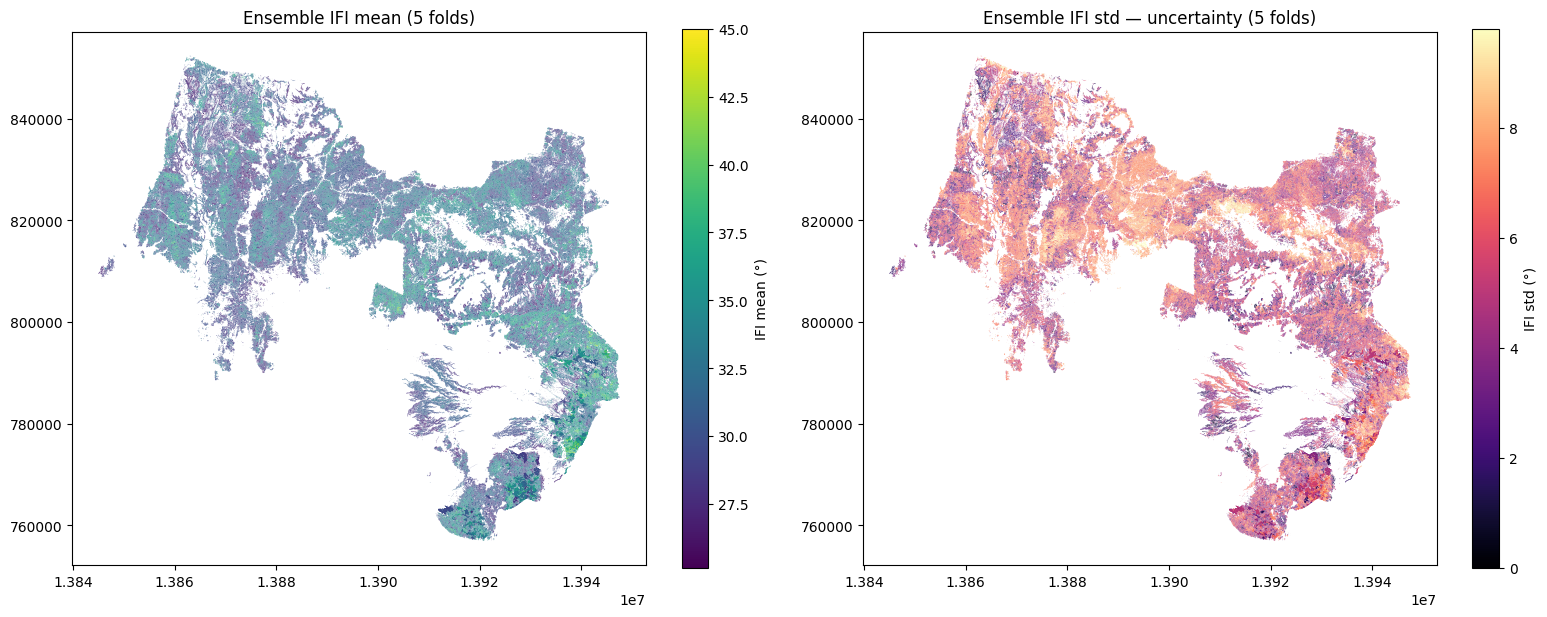

In [79]:
# IFI ensemble uncertainty — mean and std across loaded folds
post_stack = np.stack(post_list)                       # (n_folds, n_samples) in radians
ifi_mean_deg = np.degrees(post_stack.mean(axis=0))
ifi_std_deg  = np.degrees(post_stack.std(axis=0))

if len(gdf) != post_stack.shape[1]:
    raise ValueError(
        f'gdf has {len(gdf)} rows but predictions have {post_stack.shape[1]} — '
        'gdf must be built from the same diag_df.'
    )

gdf = gdf.copy()
gdf['ifi_mean'] = ifi_mean_deg
gdf['ifi_std']  = ifi_std_deg

print(f'  folds used:   {len(post_list)}')
print(f'  ifi_mean:     min={ifi_mean_deg.min():.2f}\u00b0  '
      f'mean={ifi_mean_deg.mean():.2f}\u00b0  max={ifi_mean_deg.max():.2f}\u00b0')
print(f'  ifi_std:      min={ifi_std_deg.min():.2f}\u00b0  '
      f'mean={ifi_std_deg.mean():.2f}\u00b0  max={ifi_std_deg.max():.2f}\u00b0')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

gdf.plot(
    column='ifi_mean', ax=axes[0], legend=True, alpha=0.85,
    cmap='viridis',
    legend_kwds={'label': 'IFI mean (\u00b0)', 'shrink': 0.7},
)
axes[0].set_aspect('equal')
axes[0].set_title(f'Ensemble IFI mean ({len(post_list)} folds)')

gdf.plot(
    column='ifi_std', ax=axes[1], legend=True, alpha=0.85,
    cmap='magma',
    legend_kwds={'label': 'IFI std (\u00b0)', 'shrink': 0.7},
)
axes[1].set_aspect('equal')
axes[1].set_title(f'Ensemble IFI std — uncertainty ({len(post_list)} folds)')

plt.tight_layout()
plt.show()
